In [ ]:
librarian::shelf(tidyverse,visdat,geosphere, tidymodels, propensity, dagitty, ggdag, ggokabeito, patchwork)

In [ ]:
update_theme(
    theme_minimal(base_size = 13) +
        theme(
            geom = element_geom(accent = "#E69F00"),
            plot.title = element_text(face = "bold", size = 14),
            plot.subtitle = element_text(colour = "grey40", size = 11),
            plot.caption = element_text(colour = "grey50", size = 9),
            strip.text = element_text(face = "bold"),
            legend.position = "top"
        )
)

covid_date <- as.Date("2020-03-01")

In [ ]:
data <- read_csv(here::here("data", "wfp_food_prices_ken.csv")) |> 
    slice(-1) |> 
    janitor::clean_names() |> 
    select(-currency)


Rows: 10767 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (14): date, admin1, admin2, market, latitude, longitude, category, commo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
head(data)

date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,price,usdprice
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2006-01-15,Coast,Mombasa,Mombasa,-4.05,39.666667,cereals and tubers,Maize,KG,actual,Wholesale,16.13,0.2235
2006-01-15,Coast,Mombasa,Mombasa,-4.05,39.666667,pulses and nuts,Beans,KG,actual,Wholesale,33.63,0.4659
2006-01-15,Coast,Mombasa,Mombasa,-4.05,39.666667,pulses and nuts,Beans (dry),90 KG,actual,Wholesale,3246.0,44.9705
2006-01-15,Eastern,Kitui,Kitui,-1.366667,38.016667,cereals and tubers,Maize (white),KG,actual,Retail,17.0,0.2355
2006-01-15,Eastern,Kitui,Kitui,-1.366667,38.016667,pulses and nuts,Beans (dry),KG,actual,Retail,39.0,0.5403
2006-01-15,Eastern,Marsabit,Marsabit,2.333333,37.983333,cereals and tubers,Maize (white),KG,actual,Retail,21.0,0.2909


In [ ]:
nairobi_coords <- data |>
  filter(market == "Nairobi") |>
  mutate(longitude = as.numeric(longitude),
         latitude = as.numeric(latitude)) |>  
  summarise(lon = first(longitude), lat = first(latitude))


nairobi_coords

lon,lat
<dbl>,<dbl>
36.81667,-1.283333


In [ ]:
data <- data  |> 
mutate(latitude = as.numeric(latitude),
        longitude = as.numeric(longitude),
        usdprice = as.numeric(usdprice),
        price = as.numeric(price),
        date = as.Date(date),
        period = if_else(date >= covid_date, "post_covid", "pre_covid"),
        year = lubridate::year(date),
        month = lubridate::month(date, label = TRUE),
        dist_from_nrb =  distHaversine(
      cbind(longitude, latitude),
      cbind(nairobi_coords$lon, nairobi_coords$lat)
    ) / 1000)


# EDA

In [ ]:
head(data)

date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,price,usdprice,period,year,month,dist_from_nrb
<date>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<ord>,<dbl>
2006-01-15,Coast,Mombasa,Mombasa,-4.050000,39.66667,cereals and tubers,Maize,KG,actual,Wholesale,16.13,0.2235,pre_covid,2006,Jan,441.8946
2006-01-15,Coast,Mombasa,Mombasa,-4.050000,39.66667,pulses and nuts,Beans,KG,actual,Wholesale,33.63,0.4659,pre_covid,2006,Jan,441.8946
2006-01-15,Coast,Mombasa,Mombasa,-4.050000,39.66667,pulses and nuts,Beans (dry),90 KG,actual,Wholesale,3246.00,44.9705,pre_covid,2006,Jan,441.8946
2006-01-15,Eastern,Kitui,Kitui,-1.366667,38.01667,cereals and tubers,Maize (white),KG,actual,Retail,17.00,0.2355,pre_covid,2006,Jan,133.8695
2006-01-15,Eastern,Kitui,Kitui,-1.366667,38.01667,pulses and nuts,Beans (dry),KG,actual,Retail,39.00,0.5403,pre_covid,2006,Jan,133.8695
2006-01-15,Eastern,Marsabit,Marsabit,2.333333,37.98333,cereals and tubers,Maize (white),KG,actual,Retail,21.00,0.2909,pre_covid,2006,Jan,423.0260


In [ ]:
tail(data)

date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,price,usdprice,period,year,month,dist_from_nrb
<date>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<ord>,<dbl>
2023-12-15,Rift Valley,Turkana,Mogadishu (Kakuma),3.71708,34.85033,cereals and tubers,Maize,KG,aggregate,Retail,60.0,0.3933,post_covid,2023,Dec,598.0913
2023-12-15,Rift Valley,Turkana,Mogadishu (Kakuma),3.71708,34.85033,cereals and tubers,Maize flour,KG,aggregate,Retail,92.0,0.6031,post_covid,2023,Dec,598.0913
2023-12-15,Rift Valley,Turkana,Mogadishu (Kakuma),3.71708,34.85033,cereals and tubers,Potatoes (Irish),KG,aggregate,Retail,73.0,0.4785,post_covid,2023,Dec,598.0913
2023-12-15,Rift Valley,Turkana,Mogadishu (Kakuma),3.71708,34.85033,"meat, fish and eggs",Meat (goat),KG,aggregate,Retail,800.0,5.2442,post_covid,2023,Dec,598.0913
2023-12-15,Rift Valley,Turkana,Mogadishu (Kakuma),3.71708,34.85033,miscellaneous food,Salt,200 G,aggregate,Retail,10.0,0.0656,post_covid,2023,Dec,598.0913
2023-12-15,Rift Valley,Turkana,Mogadishu (Kakuma),3.71708,34.85033,miscellaneous food,Sugar,KG,aggregate,Retail,210.5,1.3799,post_covid,2023,Dec,598.0913


In [ ]:
food <- data  |> 
filter(category != "non-food")

fuel <- data |> 
filter(category == "non-food")



In [ ]:
key_commodities <- c(
  "Maize",
  "Beans (dry)",
  "Sorghum",
  "Oil (vegetable)",
  "Potatoes (Irish)"
)

In [ ]:
data |> 
  summarise(
    markets = n_distinct(market),
    obs = n(),
    .by = admin1
  ) |> 
  arrange(desc(obs)) |> 
  print()

# A tibble: 7 × 3
  admin1        markets   obs
  <chr>           <int> <int>
1 Rift Valley        20  4163
2 Nairobi             9  2290
3 North Eastern       9  1176
4 Eastern            10  1091
5 Coast              11  1072
6 Nyanza              2   838
7 Central             1   136


In [ ]:
# Do price type change after the brea point period on average?

data  |> 
    group_by(period) |> 
    filter(commodity %in% key_commodities) |>
    filter(pricetype == "Retail")  |> 
    summarise(mean_price = mean(price, na.rm = TRUE)) |> 
    print()

# A tibble: 2 × 2
  period     mean_price
  <chr>           <dbl>
1 post_covid       108.
2 pre_covid        116.


In [ ]:
food <- food |>
  mutate(
    price = case_when(
    str_detect(commodity, "Maize") & unit == "90 KG" ~ price / 90,
    str_detect(commodity, "Potatoes") & unit == "50 KG" ~ price / 50,
    str_detect(commodity, "Sorghum") & unit == "90 KG" ~ price / 90,
    str_detect(commodity, "Beans") & unit == "90 KG" ~ price / 90,
    .default = price
  ),
  unit = case_when(
    str_detect(commodity, "Maize") & unit == "90 KG" ~ "KG",
    str_detect(commodity, "Potatoes") & unit == "50 KG" ~ "KG",
    str_detect(commodity, "Sorghum") & unit == "90 KG" ~ "KG",
    str_detect(commodity, "Beans") & unit == "90 KG" ~ "KG",
    .default = unit
  ),
    commodity = case_when(
      str_detect(commodity, "Maize") ~ "Maize",
      str_detect(commodity, "Sorghum") ~ "Sorghum",
      str_detect(commodity, "Potatoes") ~ "Potatoes (Irish)",
      commodity == "Beans (dry)" ~ "Beans (dry)",
      .default = commodity
    ),

  )

In [ ]:
price_series <- food |> 
    filter(commodity %in% key_commodities) |> 
    summarise(median_price = median(price, na.rm = TRUE), .by = c(date, commodity))

price_series |> head()


date,commodity,median_price
<date>,<chr>,<dbl>
2006-01-15,Maize,15.83722
2006-01-15,Beans (dry),39.00000
2006-01-15,Potatoes (Irish),17.38500
2006-01-15,Oil (vegetable),115.00000
2006-01-15,Sorghum,17.77778
2006-02-15,Maize,16.66611


In [ ]:
price_series |> 
 select(commodity) |> 
 distinct()

commodity
<chr>
Maize
Beans (dry)
Potatoes (Irish)
Oil (vegetable)
Sorghum


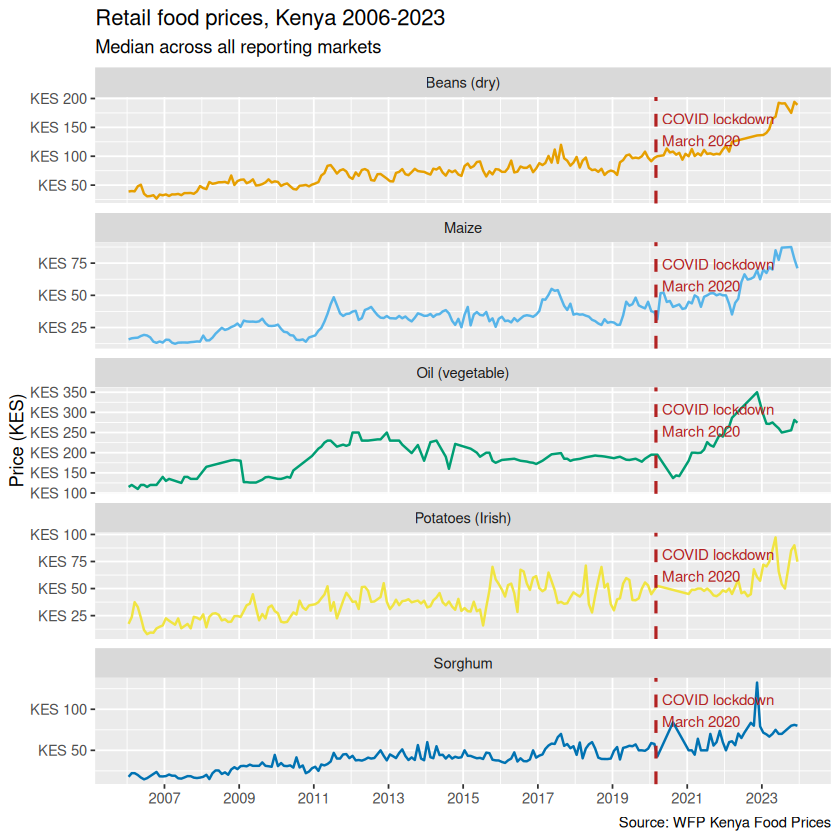

In [ ]:
p_series <- price_series |>
    ggplot(aes(x = date, y = median_price, colour = commodity)) +
    geom_line(linewidth = 0.7) +
    geom_vline(
        xintercept = covid_date,
        colour = "firebrick", linewidth = 0.9, linetype = "dashed"
    ) +
    annotate(
        "text",
        x = covid_date + 60, y = Inf,
        label = "COVID lockdown\nMarch 2020",
        vjust = 1.5, hjust = 0, size = 3.2, colour = "firebrick"
    ) +
    scale_colour_okabe_ito(name = NULL) +
    scale_y_continuous(labels = label_comma(prefix = "KES ")) +
    scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
    facet_wrap(~commodity, scales = "free_y", ncol = 1) +
    labs(
        title = "Retail food prices, Kenya 2006-2023",
        subtitle = "Median across all reporting markets",
        x = NULL,
        y = "Price (KES)",
        caption  = "Source: WFP Kenya Food Prices"
    ) +
    theme(legend.position = "none")

print(p_series)

In [ ]:
# Food prices for the 12 months before and after covid

shock_window <-food |> 
filter(
    date >= covid_date - months(12) & date <= covid_date + months(12),
    pricetype == "Retail"
) |> 
mutate(window = if_else(date < covid_date, "Pre (Mar 2019 - Feb 2020)", "Post (Mar 2020 - Feb 2021)"))

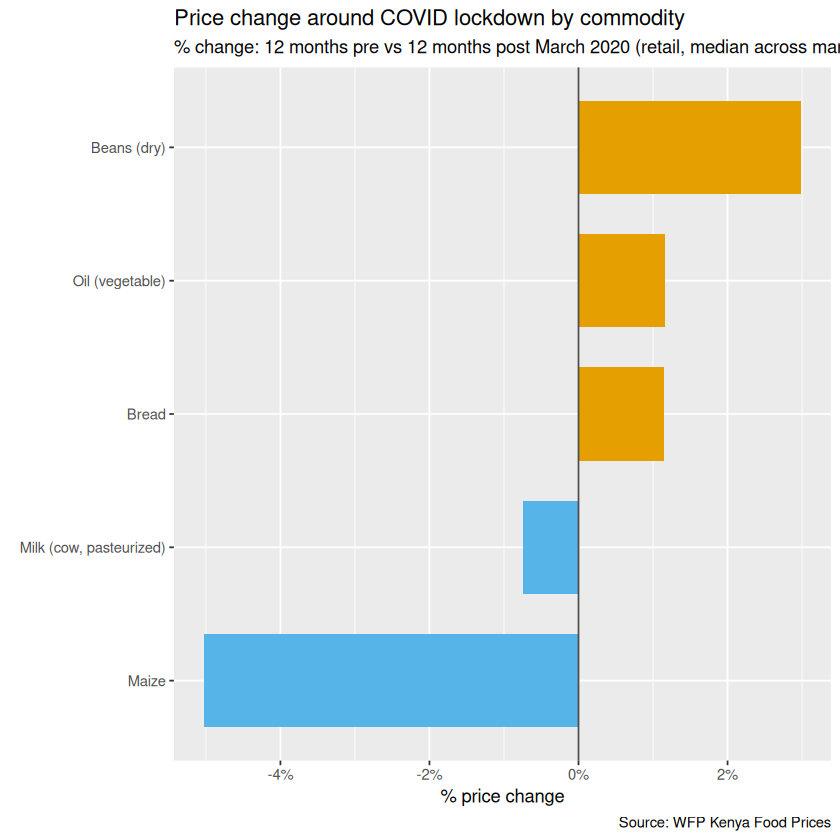

In [ ]:
pct_change <- shock_window |>
    summarise(
        median_price = median(price, na.rm = TRUE),
        .by = c(commodity, window)
    ) |>
    pivot_wider(names_from = window, values_from = median_price) |>
    janitor::clean_names() |>
    mutate(
        pct_change = (post_mar_2020_feb_2021 - pre_mar_2019_feb_2020) / pre_mar_2019_feb_2020 * 100
    ) |>
    filter(!is.na(pct_change)) |>
    arrange(desc(pct_change))

p_shock <- pct_change |>
    mutate(commodity = fct_reorder(commodity, pct_change)) |>
    ggplot(aes(x = pct_change, y = commodity, fill = pct_change > 0)) +
    geom_col(width = 0.7) +
    geom_vline(xintercept = 0, colour = "grey30", linewidth = 0.5) +
    scale_fill_manual(values = c("TRUE" = "#E69F00", "FALSE" = "#56B4E9"), guide = "none") +
    scale_x_continuous(labels = label_percent(scale = 1)) +
    labs(
        title    = "Price change around COVID lockdown by commodity",
        subtitle = "% change: 12 months pre vs 12 months post March 2020 (retail, median across markets)",
        x        = "% price change",
        y        = NULL,
        caption  = "Source: WFP Kenya Food Prices"
    )

print(p_shock)

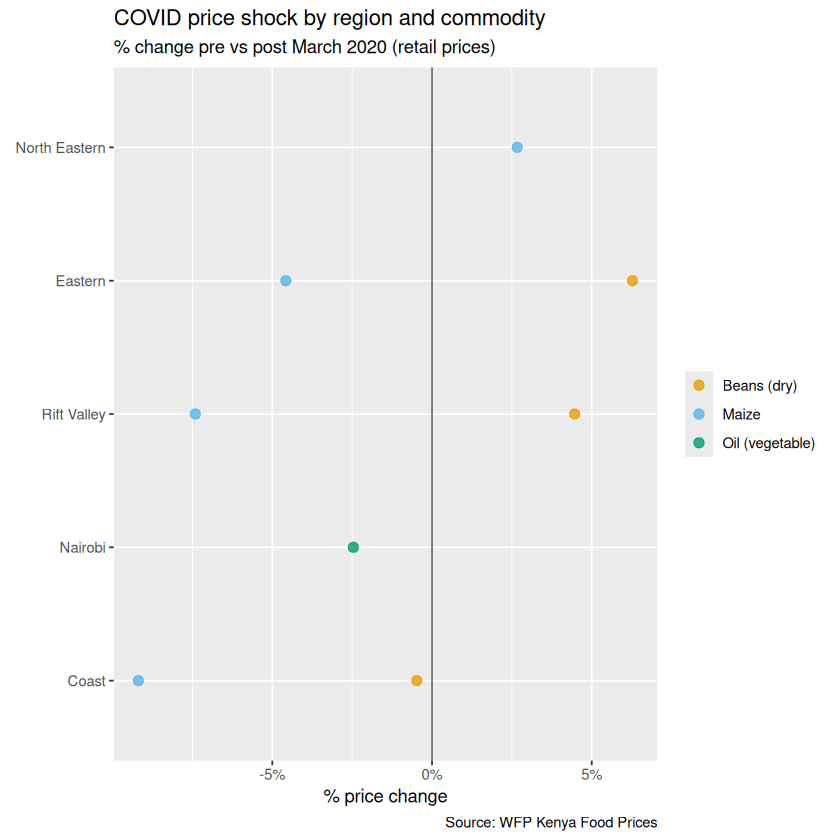

In [ ]:
regional_shock <- food |>
    filter(
        commodity %in% key_commodities,
        pricetype == "Retail",
        date >= covid_date - months(12),
        date <= covid_date + months(12)
    ) |>
    mutate(window = if_else(date < covid_date, "pre", "post")) |>
    summarise(
        median_price = median(price, na.rm = TRUE),
        .by = c(admin1, commodity, window)
    ) |>
    pivot_wider(names_from = window, values_from = median_price) |>
    mutate(pct_change = (post - pre) / pre * 100) |>
    filter(!is.na(pct_change))

p_regional <- regional_shock |>
    mutate(admin1 = fct_reorder(admin1, pct_change, .fun = median)) |>
    ggplot(aes(x = pct_change, y = admin1, colour = commodity)) +
    geom_point(size = 2.5, alpha = 0.8) +
    geom_vline(xintercept = 0, colour = "grey30", linewidth = 0.4) +
    scale_colour_okabe_ito(name = NULL) +
    scale_x_continuous(labels = label_percent(scale = 1)) +
    labs(
        title    = "COVID price shock by region and commodity",
        subtitle = "% change pre vs post March 2020 (retail prices)",
        x        = "% price change",
        y        = NULL,
        caption  = "Source: WFP Kenya Food Prices"
    )

print(p_regional)